# Klimatologie Gülpe

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

### Campell-Station ("die neue Station")

In [60]:
cdir = "/media/geoecology-user/teach/BSc_LaPra_Guelpe/data_complete/"

In [61]:
os.listdir(cdir)

['2025-10-14_Wilmers_full_hourly_data_lysi-station_2018-04-27-2025-10-14.csv',
 '2025-10-14_Wilmers_rain_data_lysi-station_2018-04-27-2025-10-14.csv',
 '2026-03-31_BF_2022-01-20_2026-02-17_.csv',
 '2026-03-31_DK_2022-01-20_2026-02-17_.csv',
 '2026-03-31_Logger_2016-10-13_2026-02-17_.csv',
 '2026-03-31_Pegel_2018-11-29_2026-02-17_.csv',
 '2026-03-31_Public_2016-12-17_2024-09-10_.csv',
 '2026-03-31_Regen_2016-10-13_2026-02-17_.csv',
 '2026-03-31_Status_2016-12-17_2024-09-10_.csv',
 '2026-03-31_Strahlung_2016-10-13_2026-02-17_.csv',
 '2026-03-31_Temp_2016-10-13_2026-02-17_.csv',
 '2026-03-31_Thiess_extrem_2009-07-27_2026-03-30_.csv',
 '2026-03-31_Thiess_mittel_2008-12-02_2026-03-30_.csv',
 '2026-03-31_Wind_2016-10-13_2026-02-17_.csv']

In [62]:
varnames = "BF", "DK", "Pegel", "Regen", "Strahlung", "Temp", "Wind"

In [63]:
data = {}
for f in os.listdir(cdir):
    print(f)
    for varname in varnames:
        if varname in f:
            fpath = os.path.join(cdir, f)
            df = pd.read_csv(fpath)
            df["datetime"] = pd.to_datetime(df.timestamp)
            df = df.set_index("datetime")
            df = df.drop(columns=["timestamp","record"])
            if not df.index.is_unique:
                print("   WARNING: contains %d duplicates - keeping only first..." % df.index.duplicated(keep="first").sum() )
            df = df[~df.index.duplicated(keep="first")]
            data[varname] = df   

2025-10-14_Wilmers_full_hourly_data_lysi-station_2018-04-27-2025-10-14.csv
2025-10-14_Wilmers_rain_data_lysi-station_2018-04-27-2025-10-14.csv
2026-03-31_BF_2022-01-20_2026-02-17_.csv
2026-03-31_DK_2022-01-20_2026-02-17_.csv
2026-03-31_Logger_2016-10-13_2026-02-17_.csv
2026-03-31_Pegel_2018-11-29_2026-02-17_.csv
2026-03-31_Public_2016-12-17_2024-09-10_.csv
2026-03-31_Regen_2016-10-13_2026-02-17_.csv
2026-03-31_Status_2016-12-17_2024-09-10_.csv
2026-03-31_Strahlung_2016-10-13_2026-02-17_.csv
2026-03-31_Temp_2016-10-13_2026-02-17_.csv
2026-03-31_Thiess_extrem_2009-07-27_2026-03-30_.csv
2026-03-31_Thiess_mittel_2008-12-02_2026-03-30_.csv
2026-03-31_Wind_2016-10-13_2026-02-17_.csv


In [64]:
dfc = pd.concat([data["Temp"], data["Wind"], data["Strahlung"], data["Regen"]], axis=1)

In [65]:
dfc.columns

Index(['air.temp.deg.C.avg.1', 'rh.perc.smp.1', 'air.temp.deg.C.avg.2',
       'rh.perc.smp.2', 'T107.deg.C.avg.1', 'T107.deg.C.avg.2',
       'T107.deg.C.avg.3', 'WS.ms.S.WVT.Wvc', 'wind.dir.d1.deg.WVT.Wvc',
       'WSDiag.smp', 'SUp.avg_W/m²', 'SDn_Avg_W/m²', 'LUp_Avg_W/m²',
       'LDn_Avg_W/m²', 'CNR4TC_Avg_Deg C', 'CNR4TK_Avg_K', 'RsNet_Avg_W/m²',
       'RlNet_Avg_W/m²', 'Albedo_Avg_W/m²', 'Rn_Avg_W/m²', 'LUpCo_Avg_W/m²',
       'LDnCo_Avg_W/m²', 'rain.mm.tot'],
      dtype='object')

| Spaltenname               | Bedeutung                                           | Einheit                   | Vermutlicher Sensor                            |
| ------------------------- | --------------------------------------------------- | ------------------------- | ---------------------------------------------- |
| `air.temp.deg.C.avg.1`    | Lufttemperatur in 200 cm               | °C                        | Temperatur-/Feuchtesensor (z.B. HMP155, HC2S3) |
| `rh.perc.smp.1`           | Relative Luftfeuchte in 200 cm                     | %                         | gleicher Sensor                                |
| `air.temp.deg.C.avg.2`    | Lufttemperatur in 50 cm                           | °C                        | zweiter Temperatur-/Feuchtesensor              |
| `rh.perc.smp.2`           | Relative Luftfeuchte in 50 cm                     | %                         | zweiter Sensor                                 |
| `T107.deg.C.avg.1`        | Bodentemperatur in 5 cm Tiefe                       | °C                        | Campbell T107 Thermistor                       |
| `T107.deg.C.avg.2`        | Bodentemperatur in 20 cm Tiefe                       | °C                        | T107                                           |
| `T107.deg.C.avg.3`        | Bodentemperatur in 50 cm Tiefe                       | °C                        | T107                                           |
| `WS.ms.S.WVT.Wvc`         | Windgeschwindigkeit in 200 cm         | m s⁻¹                     | Windmonitor (z.B. RM Young)                    |
| `wind.dir.d1.deg.WVT.Wvc` | Windrichtung in 200 cm                | °                         | Windmonitor                                    |
| `WSDiag.smp`              | Diagnosecode des Windsensors                        | -                         | Windmonitor                                    |
| `SUp.avg_W/m²`            | Kurzwellige Strahlung nach unten (Globalstrahlung)                       | W m⁻²                     | CNR4                                           |
| `SDn_Avg_W/m²`            | Kurzwellige Strahlung nach oben      | W m⁻²                     | CNR4                                           |
| `LUp_Avg_W/m²`            | Langwellige Strahlung nach oben                       | W m⁻²                     | CNR4                                           |
| `LDn_Avg_W/m²`            | Langwellige Strahlung nach unten                        | W m⁻²                     | CNR4                                           |
| `CNR4TC_Avg_Deg C`        | Gehäusetemperatur des CNR4                          | °C                        | CNR4                                           |
| `CNR4TK_Avg_K`            | Gehäusetemperatur des CNR4                          | K                         | CNR4                                           |
| `RsNet_Avg_W/m²`          | Netto-Kurzwellensaldo = SUp − SDn                   | W m⁻²                     | berechnet                                      |
| `RlNet_Avg_W/m²`          | Netto-Langwellensaldo = LDn − LUp                   | W m⁻²                     | berechnet                                      |
| `Albedo_Avg_W/m²`         | Albedo=SUp/SDn (nur tagsüber)          | - | berechnet                                      |
| `Rn_Avg_W/m²`             | Netto-Strahlungsbilanz                              | W m⁻²                     | berechnet                                      |
| `LUpCo_Avg_W/m²`          | Temperaturkorrigierte langwellige Aufwärtsstrahlung | W m⁻²                     | CNR4                                           |
| `LDnCo_Avg_W/m²`          | Temperaturkorrigierte langwellige Abwärtsstrahlung  | W m⁻²                     | CNR4                                           |
| `rain.mm.tot`             | Niederschlagssumme                                  | mm                        | Kippwaage                                      |


<Axes: xlabel='datetime'>

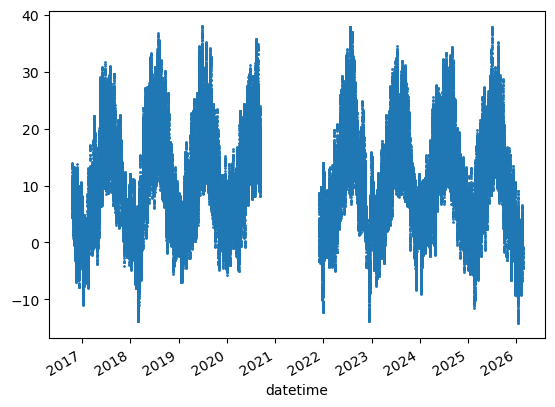

In [66]:
dfc.loc["2016-05-01":, "air.temp.deg.C.avg.1"].plot(marker="o", ms=1, lw=0)

In [67]:
dfcsub = dfc.loc[(dfc.index.dayofyear>=245) & (dfc.index.dayofyear<=271)]
dfcsubh = dfcsub.resample("h").mean()
dfcday = dfcsubh.groupby(dfcsubh.index.hour).mean()
dfcday.index += 1
dfcday

,air.temp.deg.C.avg.1,rh.perc.smp.1,air.temp.deg.C.avg.2,rh.perc.smp.2,T107.deg.C.avg.1,T107.deg.C.avg.2,T107.deg.C.avg.3,WS.ms.S.WVT.Wvc,wind.dir.d1.deg.WVT.Wvc,WSDiag.smp,...,LDn_Avg_W/m²,CNR4TC_Avg_Deg C,CNR4TK_Avg_K,RsNet_Avg_W/m²,RlNet_Avg_W/m²,Albedo_Avg_W/m²,Rn_Avg_W/m²,LUpCo_Avg_W/m²,LDnCo_Avg_W/m²,rain.mm.tot
datetime,,,,,,,,,,,,,,,,,,,,,
1,12.271982,91.863719,11.282854,93.646298,15.442546,15.921742,15.715879,1.503915,181.064518,0.0,...,-6.207521,11.812660,284.961307,-2.612590,-29.562966,inf,-32.175382,338.437521,367.999832,0.001492
2,11.916340,92.944188,10.955698,94.566047,15.257672,15.908442,15.720637,1.493663,179.977650,0.0,...,-5.696214,11.453390,284.600670,-2.663109,-28.511590,inf,-31.174816,338.111893,366.626131,0.000874
3,11.596444,93.835528,10.660630,95.323015,15.082379,15.887069,15.722898,1.474982,183.835219,0.0,...,-5.263353,11.100698,284.251591,-2.664162,-26.882099,NaN,-29.546350,338.337018,365.219933,0.002418
4,11.338348,94.295327,10.439791,95.673802,14.917990,15.857638,15.721993,1.481752,178.964194,0.0,...,-4.887236,10.836310,283.986432,-2.711333,-26.080866,NaN,-28.792229,338.143886,364.225293,0.001955
5,11.148529,94.878710,10.320476,96.072261,14.763886,15.821206,15.717990,1.491901,183.857672,0.0,...,-4.363183,10.615340,283.766834,-2.568729,-24.119064,NaN,-26.687869,339.476717,363.596817,0.002366
6,11.260387,94.448023,10.537449,95.636097,14.625628,15.780704,15.711709,1.542724,176.165265,0.0,...,-3.888070,10.443620,283.593970,-1.996198,-22.952523,NaN,-24.948848,340.241206,363.195477,0.002932
7,11.729377,92.812948,11.203427,93.844020,14.520653,15.733652,15.701156,1.553596,173.862819,0.0,...,-2.588389,10.643161,283.794472,19.371575,-25.114940,inf,-5.743310,340.416415,365.530653,0.007099
8,13.260946,88.974740,13.160072,89.835662,14.473752,15.682630,15.686432,1.880147,172.269211,0.0,...,0.068000,12.444099,285.594137,93.415370,-35.811953,0.202910,57.603456,341.770017,377.585092,0.002726
9,15.078037,83.190724,15.206300,84.206380,14.532256,15.625471,15.664057,2.302777,178.643600,0.0,...,3.987451,14.796913,287.947236,186.034005,-53.825442,0.184241,132.209005,340.267839,394.094640,0.001543


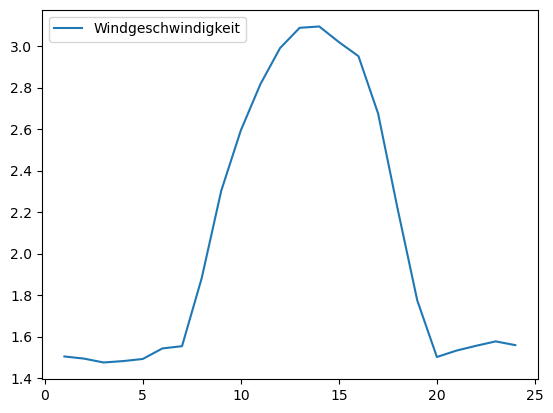

In [68]:
fig, ax = plt.subplots(1,1)
#plt.plot(dfcday.index, dfcday["SDn_Avg_W/m²"]/dfcday["SUp.avg_W/m²"], label="SUp")
#plt.plot(dfcday.index, dfcday["Albedo_Avg_W/m²"], label="Albedo")
plt.plot(dfcday.index, dfcday["WS.ms.S.WVT.Wvc"], label="Windgeschwindigkeit")
plt.legend()

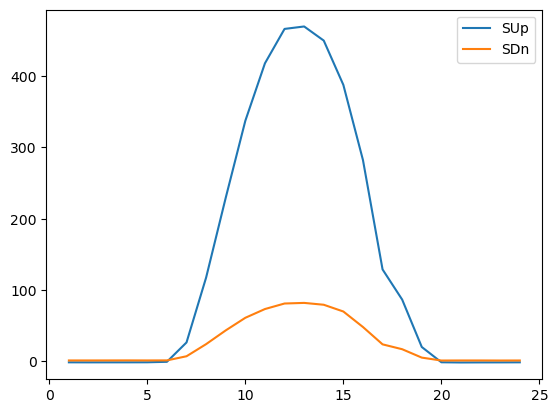

In [69]:
fig, ax = plt.subplots(1,1)
plt.plot(dfcday.index, dfcday["SUp.avg_W/m²"], label="SUp")
plt.plot(dfcday.index, dfcday["SDn_Avg_W/m²"], label="SDn")
# plt.plot(dfcday.index, dfcday["LUp_Avg_W/m²"], label="LUp")
# plt.plot(dfcday.index, dfcday["LDn_Avg_W/m²"], label="LDn")
plt.legend()

#### Export

In [70]:
dfcday.columns

Index(['air.temp.deg.C.avg.1', 'rh.perc.smp.1', 'air.temp.deg.C.avg.2',
       'rh.perc.smp.2', 'T107.deg.C.avg.1', 'T107.deg.C.avg.2',
       'T107.deg.C.avg.3', 'WS.ms.S.WVT.Wvc', 'wind.dir.d1.deg.WVT.Wvc',
       'WSDiag.smp', 'SUp.avg_W/m²', 'SDn_Avg_W/m²', 'LUp_Avg_W/m²',
       'LDn_Avg_W/m²', 'CNR4TC_Avg_Deg C', 'CNR4TK_Avg_K', 'RsNet_Avg_W/m²',
       'RlNet_Avg_W/m²', 'Albedo_Avg_W/m²', 'Rn_Avg_W/m²', 'LUpCo_Avg_W/m²',
       'LDnCo_Avg_W/m²', 'rain.mm.tot'],
      dtype='object')

In [71]:
# rename
dfcday.columns = ['temp200', 'rh200', 'temp50',
       'rh50', 'bodentemp5', 'bodentemp20',
       'bodentemp50', 'windgeschw200', 'winddir200',
       'WSDiag.smp', 'globalstrahlung', 'kurzwUP', 'langwUP',
       'langwDOWN', 'CNR4TC_Avg_Deg C', 'CNR4TK_Avg_K', 'RsNet_Avg_W/m²',
       'RlNet_Avg_W/m²', 'Albedo_Avg_W/m²', 'nettostrahlung', 'LUpCo_Avg_W/m²',
       'LDnCo_Avg_W/m²', 'rain.mm.tot']
# select
dfcday = dfcday[['temp200', 'rh200', 'temp50', 'rh50', 'bodentemp5', 'bodentemp20',
          'bodentemp50', 'windgeschw200', 'winddir200', 'globalstrahlung', 
          'kurzwUP', 'langwUP', 'langwDOWN', "nettostrahlung"]]

In [72]:
dfcday

,temp200,rh200,temp50,rh50,bodentemp5,bodentemp20,bodentemp50,windgeschw200,winddir200,globalstrahlung,kurzwUP,langwUP,langwDOWN,nettostrahlung
datetime,,,,,,,,,,,,,,
1,12.271982,91.863719,11.282854,93.646298,15.442546,15.921742,15.715879,1.503915,181.064518,-1.422586,1.190090,-35.770648,-6.207521,-32.175382
2,11.916340,92.944188,10.955698,94.566047,15.257672,15.908442,15.720637,1.493663,179.977650,-1.478055,1.185062,-34.208057,-5.696214,-31.174816
3,11.596444,93.835528,10.660630,95.323015,15.082379,15.887069,15.722898,1.474982,183.835219,-1.448097,1.215884,-32.145387,-5.263353,-29.546350
4,11.338348,94.295327,10.439791,95.673802,14.917990,15.857638,15.721993,1.481752,178.964194,-1.435357,1.275946,-30.968240,-4.887236,-28.792229
5,11.148529,94.878710,10.320476,96.072261,14.763886,15.821206,15.717990,1.491901,183.857672,-1.367342,1.201280,-28.482444,-4.363183,-26.687869
6,11.260387,94.448023,10.537449,95.636097,14.625628,15.780704,15.711709,1.542724,176.165265,-0.712821,1.283397,-26.840643,-3.888070,-24.948848
7,11.729377,92.812948,11.203427,93.844020,14.520653,15.733652,15.701156,1.553596,173.862819,26.453605,7.081377,-27.703317,-2.588389,-5.743310
8,13.260946,88.974740,13.160072,89.835662,14.473752,15.682630,15.686432,1.880147,172.269211,117.512978,24.097863,-35.743293,0.068000,57.603456
9,15.078037,83.190724,15.206300,84.206380,14.532256,15.625471,15.664057,2.302777,178.643600,229.382216,43.349136,-49.838280,3.987451,132.209005


In [73]:
dfcday.to_csv("daten/tagesgang-klimastation-september.csv", float_format="%.2f", index_label="hourofday", sep=",")

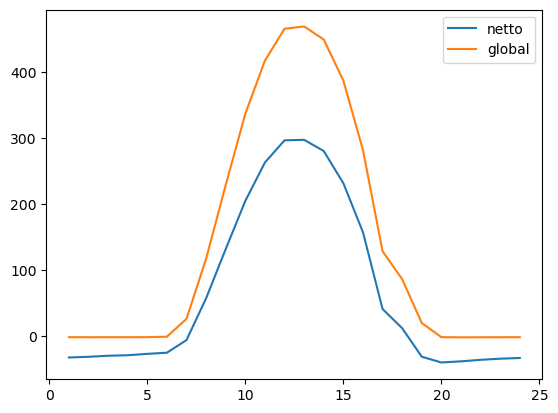

In [74]:
fig, ax = plt.subplots(1,1)
plt.plot(dfcday.index, dfcday["nettostrahlung"], label="netto")
plt.plot(dfcday.index, dfcday["globalstrahlung"], label="global")
# plt.plot(dfcday.index, dfcday["LUp_Avg_W/m²"], label="LUp")
# plt.plot(dfcday.index, dfcday["LDn_Avg_W/m²"], label="LDn")
plt.legend()

In [75]:
es = 0.6108 * np.exp(17.27*dfcday.temp200/(237.3+dfcday.temp200))
delta = es * 4098 / ((dfcday.temp200+237.3)**2)
pet = 0.00185 * dfcday.nettostrahlung * delta/(delta+0.066)
pet = np.array([max(i, 0) for i in pet])
pet.sum()

2.459418802991706

#### Wind

In [ ]:
# First half of September
dfwindsub = df.loc[(df["Wind"].index.month==9) & (df["Wind"].index.day>1) & (df["Wind"].index.day<15)]
dftsubday = dftsub.groupby(dftsub.index.hour).mean()
dftsubday.index += 1
dftsubday.to_csv("daten/mittel-tagesgang-sep-thies.csv", float_format="%.2f")

In [9]:
data["Wind"].columns

Index(['record', 'WS.ms.S.WVT.Wvc', 'wind.dir.d1.deg.WVT.Wvc', 'WSDiag.smp'], dtype='object')

#### Strahlung

In [8]:
data["Strahlung"].columns#["air.temp.deg.C.avg.1"].plot()
#data["Pegel"]["level.cm.avg"].plot()


Index(['record', 'SUp.avg_W/m²', 'SDn_Avg_W/m²', 'LUp_Avg_W/m²',
       'LDn_Avg_W/m²', 'CNR4TC_Avg_Deg C', 'CNR4TK_Avg_K', 'RsNet_Avg_W/m²',
       'RlNet_Avg_W/m²', 'Albedo_Avg_W/m²', 'Rn_Avg_W/m²', 'LUpCo_Avg_W/m²',
       'LDnCo_Avg_W/m²'],
      dtype='object')

### Thies-Station (alt)

In [29]:
dft = pd.read_csv("/media/geoecology-arbeitsgruppen/Hydrologie/rene/Guelpe/Thies/2025-09-30_Thiess_mittel_2008-12-02_2025-09-30_.csv",
                 na_values=["????.?",""],
                 skipinitialspace=True, )
dft["datetime"] = pd.to_datetime(dft.timestamp)
dft = dft.set_index("datetime")
dft = dft.drop(columns=["timestamp","date","time","timestamp.dec","file"])

In [30]:
dft

,wind.speed.ms,wind.dir.deg,air.temp.2m.degC,air.hum.2m.perc,air.pres.hPa,radiation.Wm2,prec.mm,water.temp.degC
datetime,,,,,,,,
2008-12-02 14:00:00+00:00,3.2,221.0,5.4,86.4,NaN,0.0,0.0,4.2
2008-12-02 14:30:00+00:00,3.5,214.0,5.1,87.8,NaN,0.0,0.0,4.2
2008-12-02 15:00:00+00:00,3.8,207.0,4.9,87.0,NaN,0.0,0.0,4.1
2008-12-02 15:30:00+00:00,3.5,209.0,4.4,87.6,NaN,0.0,0.0,4.0
2008-12-02 16:00:00+00:00,3.6,203.0,3.7,89.9,NaN,0.0,0.0,3.9
...,...,...,...,...,...,...,...,...
2025-09-30 11:30:00+00:00,3.5,76.0,14.2,55.8,NaN,533.0,0.0,10.9
2025-09-30 12:00:00+00:00,3.4,109.0,15.3,50.6,NaN,565.0,0.0,11.0
2025-09-30 12:30:00+00:00,3.2,74.0,14.3,53.7,NaN,498.0,0.0,11.2


In [32]:
dft.columns, dft.shape

(Index(['wind.speed.ms', 'wind.dir.deg', 'air.temp.2m.degC', 'air.hum.2m.perc',
        'air.pres.hPa', 'radiation.Wm2', 'prec.mm', 'water.temp.degC'],
       dtype='object'),
 (275667, 8))

In [44]:
# First half of September
dftsub = dft.loc[(dft.index.month==9) & (dft.index.day>1) & (dft.index.day<15)]
dftsubday = dftsub.groupby(dftsub.index.hour).mean()
dftsubday.index += 1
dftsubday.to_csv("daten/mittel-tagesgang-sep-thies.csv", float_format="%.2f")

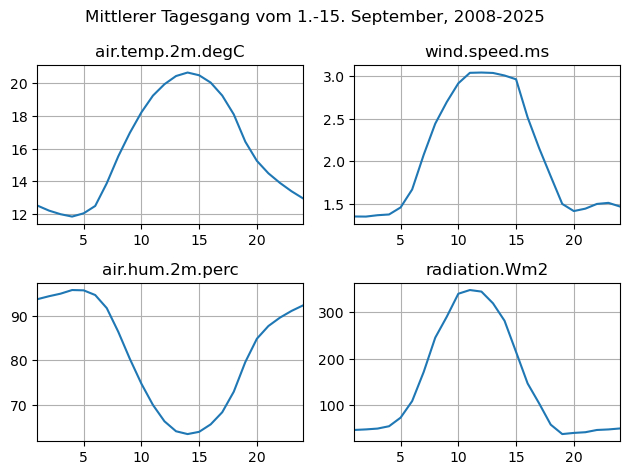

In [46]:
fig, ax = plt.subplots(2,2)
ax = ax.ravel()
for i, col in enumerate(['air.temp.2m.degC', 'wind.speed.ms', 'air.hum.2m.perc', 'radiation.Wm2']):
    plt.sca(ax[i])
    plt.plot(dftsubday.index, dftsubday[col])
    plt.grid()
    plt.title(col)
    plt.xlim(1,24)
plt.suptitle("Mittlerer Tagesgang vom 1.-15. September, 2008-2025")
plt.tight_layout()    